# **0- Environment & Data Setup**

In [1]:
!pip install lifelines shap xgboost -q

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 8.5 MB/s eta 0:00:00


In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.figure_factory as ff
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, classification_report, RocCurveDisplay
import shap
from lifelines import KaplanMeierFitter, CoxPHFitter
from sklearn.metrics import roc_curve
from sklearn.metrics import confusion_matrix


In [3]:
df = pd.read_csv("/content/Churn_Modelling.csv")
print(df.shape)
df.head()

(10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
dtype_df = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes,
    "Unique Values": df.nunique(),
    "Missing values":df.isnull().sum()

})

dtype_df

,Column,Data Type,Unique Values,Missing values
RowNumber,RowNumber,int64,10000,0
CustomerId,CustomerId,int64,10000,0
Surname,Surname,object,2932,0
CreditScore,CreditScore,int64,460,0
Geography,Geography,object,3,0
Gender,Gender,object,2,0
Age,Age,int64,70,0
Tenure,Tenure,int64,11,0
Balance,Balance,float64,6382,0
NumOfProducts,NumOfProducts,int64,4,0


In [5]:
df = df.drop(columns=['RowNumber', 'CustomerId',
'Surname'])

# **1- Exploratory Data Analysis**

## **1-0- Churn rate**

In [6]:
df['Exited'].value_counts(normalize=True)

,proportion
Exited,
0,0.7963
1,0.2037


Roughly **20% churn / 80% retained** — a moderately imbalanced target.
This rules out plain accuracy as an evaluation metric going forward and
justifies the `class_weight="balanced"` choice used later in Part 3.

## **1-1- Churn rate by category**

In [7]:
churn_by_geo = df.groupby("Geography")["Exited"].mean()
print(churn_by_geo)


Geography
France     0.161548
Germany    0.324432
Spain      0.166734
Name: Exited, dtype: float64


In [8]:
churn_by_geo = df.groupby("IsActiveMember")["Exited"].mean()
print(churn_by_geo)

IsActiveMember
0    0.268509
1    0.142691
Name: Exited, dtype: float64


In [9]:
churn_by_geo = df.groupby("NumOfProducts")["Exited"].mean()
print(churn_by_geo)

NumOfProducts
1    0.277144
2    0.075817
3    0.827068
4    1.000000
Name: Exited, dtype: float64


In [10]:
geo_rates = df.groupby("Geography")["Exited"].mean().reset_index()
active_rates = df.groupby("IsActiveMember")["Exited"].mean().reset_index()
product_rates = df.groupby("NumOfProducts")["Exited"].mean().reset_index()

fig = make_subplots(rows=1, cols=3, subplot_titles=(
    "Churn rate by Geography", "Active vs inactive members", "Churn rate by number of products"
))

fig.add_trace(go.Bar(x=geo_rates["Geography"], y=geo_rates["Exited"],
                      marker_color="#5B3A8E", showlegend=False), row=1, col=1)
fig.add_trace(go.Bar(x=active_rates["IsActiveMember"].astype(str), y=active_rates["Exited"],
                      marker_color="#1F8A87", showlegend=False), row=1, col=2)
fig.add_trace(go.Bar(x=product_rates["NumOfProducts"].astype(str), y=product_rates["Exited"],
                      marker_color="#E8664B", showlegend=False), row=1, col=3)

fig.update_yaxes(title_text="Churn rate", range=[0, 1])
fig.update_layout(height=400, width=1100, title_text="Churn rate by category")
fig.show()


**Germany** churns more than France/Spain, **inactive members** churn
much more, and customers with **3-4 products** churn almost entirely

## **1-2- Age distribution by churn status**

In [11]:
churned = df.loc[df["Exited"] == 1, "Age"]
stayed = df.loc[df["Exited"] == 0, "Age"]

fig = ff.create_distplot(
    [stayed, churned],
    group_labels=["Stayed", "Churned"],
    show_hist=False,
    show_rug=False,
    colors=["#1F8A87", "#E8664B"]
)
fig.update_layout(title="Age distribution: churned vs stayed", xaxis_title="Age", yaxis_title="Density")
fig.show()

Churned customers skew visibly older: their distribution peaks around
mid-40s versus mid-30s for those who stayed, and the churned curve carries
a longer tail out toward 60-80.

This is the clearest single univariate
signal in the whole EDA and lines up exactly with the Cox model's positive
Age coefficient (exp(coef) = 1.05) — older customers face measurably
higher churn hazard, and it's visible before any model is even trained.

## **1-3- Correlation heatmap**

In [12]:
numeric_cols = df.select_dtypes(include=np.number).columns
corr = df[numeric_cols].corr()

fig = px.imshow(
    corr,
    text_auto=".2f",
    color_continuous_scale="RdBu_r",
    zmin=-1, zmax=1,
    aspect="auto"
)
fig.update_layout(title="Correlation between numeric features", height=600, width=700)
fig.show()

The heatmap shows a well-balanced set of features.
No high correlation between variables

# **2- Feature Engineering**

## **2-1- Encoding**

In [13]:
df["Gender"] = df["Gender"].map({"Male": 0, "Female": 1})

In [14]:
df = pd.get_dummies(df, columns=["Geography"], drop_first=True)

## **2-2- Finance-specific features**

### **2-2-1- Balance-to-salary**

This feature shows how much of their income sits as balance with the bank

--> a very low ratio can signal disengagement.

In [15]:
df["BalanceSalaryRatio"] = df["Balance"] / (df["EstimatedSalary"] + 1)

### **2-2-2- Engagement score**

This feature is a simple combined signal from activity + card ownership.

--> ranges 0(disengaged) to 2 (active + has card)

In [16]:
df["EngagementScore"] = df["IsActiveMember"] + df["HasCrCard"]

### **2-2-3- Data Split**

In [17]:
X = df.drop(columns=["Exited"])
y = df["Exited"]

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
 X, y, test_size=0.2, random_state=42, stratify=y
 )

In [19]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# **3- Classification modeling**

## **3-1- Logistic Regression baseline**

In [20]:
log_reg = LogisticRegression(class_weight="balanced", max_iter=1000)
log_reg.fit(X_train_scaled, y_train)
log_reg_probs = log_reg.predict_proba(X_test_scaled)[:, 1]

## **3-2- Random Forest**

In [21]:
rf = RandomForestClassifier(
 n_estimators=300, max_depth=8, class_weight="balanced", random_state=42
)
rf.fit(X_train, y_train)
rf_probs = rf.predict_proba(X_test)[:, 1]

## **3-3- XGBoost**

In [22]:
xgb = XGBClassifier(
 n_estimators=300, max_depth=4, learning_rate=0.05,
 scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
 eval_metric="logloss", random_state=42
)

xgb.fit(X_train, y_train)
xgb_probs = xgb.predict_proba(X_test)[:, 1]

### **Models comparaison**

In [23]:
for name, probs in [("Logistic Regression", log_reg_probs),
 ("Random Forest", rf_probs),
 ("XGBoost", xgb_probs)]:
 print(f"{name}: AUC = {roc_auc_score(y_test, probs):.3f}")

Logistic Regression: AUC = 0.777
Random Forest: AUC = 0.864
XGBoost: AUC = 0.868


In [35]:
fig = go.Figure()
for name, probs in [("Logistic Regression", log_reg_probs),
 ("Random Forest", rf_probs),
 ("XGBoost", xgb_probs)]:
 fpr, tpr, _ = roc_curve(y_test, probs)
 # roc_curve returns the false/true positive rate at every possible threshold,
 # not just 0.5 -- this is what the AUC score actually summarizes into one number
 auc = roc_auc_score(y_test, probs)
 fig.add_trace(go.Scatter(x=fpr, y=tpr, mode="lines",
 name=f"{name} (AUC={auc:.3f})"))
# diagonal reference line = a model with no predictive power (random guessing)
fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode="lines",
 line=dict(dash="dash", color="grey"),
 name="Random guess"))
fig.update_layout(title="ROC curve comparison across models",
 xaxis_title="False Positive Rate",
 yaxis_title="True Positive Rate",
 width=700, height=500)
fig.show()

In [37]:
xgb_preds = (xgb_probs >= 0.5).astype(int) # turn XGBoost probabilities into 0/1 at cutoff 0.5
cm = confusion_matrix(y_test, xgb_preds)
# cm is a 2x2 grid: rows = actual class, columns = predicted class
# [[true negatives, false positives], [false negatives, true positives]]
fig = px.imshow(
 cm,
 text_auto=True, # writes the raw count inside each cell
 labels=dict(x="Predicted", y="Actual", color="Count"),
 x=["Stayed (0)", "Churned (1)"],
 y=["Stayed (0)", "Churned (1)"],
 color_continuous_scale="Purples"
)
fig.update_layout(title="Confusion matrix — XGBoost (threshold = 0.5)", width=500, height=500)
fig.show()

**[XGBoost]** comes out highest on AUC ([0.868]), meaning it separates
churners from non-churners best across all thresholds, not just at 0.5.

This is the model carried forward into SHAP and the business layer —
Random Forest / XGBoost typically edge out Logistic Regression here since
churn drivers (e.g. NumOfProducts) interact non-linearly, which a linear
model can't capture as well.

In [24]:
models = {
    "Logistic Regression": log_reg_probs,
    "Random Forest": rf_probs,
    "XGBoost": xgb_probs,
}

rows = []
for name, probs in models.items():
    preds = (probs >= 0.5).astype(int)     # turn probabilities into 0/1 at cutoff 0.5
    report = classification_report(y_test, preds, output_dict=True)
    # output_dict=True returns a nested dict instead of printed text,
    # so we can pull individual numbers out of it

    rows.append({
        "Model": name,
        "Precision": report["1"]["precision"],       # class 1 = churned
        "Recall": report["1"]["recall"],
        "F1-Score": report["1"]["f1-score"],
        "Support": report["1"]["support"],            # number of actual churners in test set
        "Accuracy": report["accuracy"],                # single overall number, not per-class
        "Macro Avg F1": report["macro avg"]["f1-score"],       # unweighted average across classes
        "Weighted Avg F1": report["weighted avg"]["f1-score"], # average weighted by class size
    })

comparison_df = pd.DataFrame(rows).set_index("Model")
comparison_df.round(3)

,Precision,Recall,F1-Score,Support,Accuracy,Macro Avg F1,Weighted Avg F1
Model,,,,,,,
Logistic Regression,0.387,0.698,0.498,407.0,0.714,0.649,0.738
Random Forest,0.547,0.695,0.613,407.0,0.821,0.748,0.828
XGBoost,0.512,0.744,0.607,407.0,0.804,0.738,0.816


**Precision vs recall trade-off:** for a retention use case, missing an
actual churner (low recall) costs more than a false alarm (low precision) —
a wrongly flagged customer just gets an unnecessary retention call, a missed
one is lost revenue.

**[XGBoost]** gives the best recall on the churn
class at [0.744], making it the more business-appropriate choice even if
another model edges it out on raw accuracy.

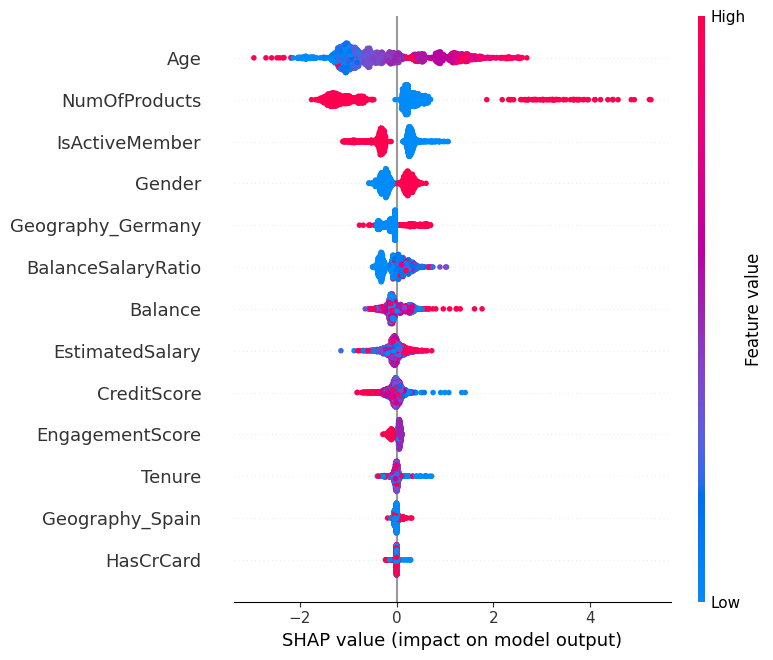

In [25]:
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

**Age, NumOfProducts, and IsActiveMember** dominate the top of the plot,
confirming the EDA findings in Part 1 with model-level evidence rather than
just group averages.

The color pattern on NumOfProducts (red dots pushed
right) shows holding 3-4 products increases churn risk sharply — this is
the strongest single driver in the model, worth leading with on the
dashboard.

# **4- Survival Analysis**

## **4-1- Kaplan-Meier : Overall survival curve**

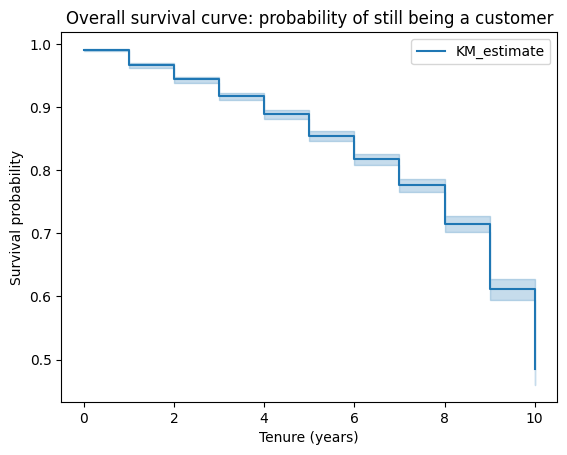

In [26]:
kmf = KaplanMeierFitter()
kmf.fit(durations=df["Tenure"], event_observed=df["Exited"])
kmf.plot_survival_function()
plt.title("Overall survival curve: probability of still being a customer")
plt.xlabel("Tenure (years)")
plt.ylabel("Survival probability")
plt.show()


The survival curve stays close to 1.0 for the first ~2 years, then declines
steadily — churn risk isn't concentrated at onboarding, it builds up over
the relationship.

By year **8**, survival probability has dropped to roughly
**0.6**, meaning about **40 %** of customers have left the bank by then.

## **4-2- Kaplan-Meier stratified by NumOfProducts**

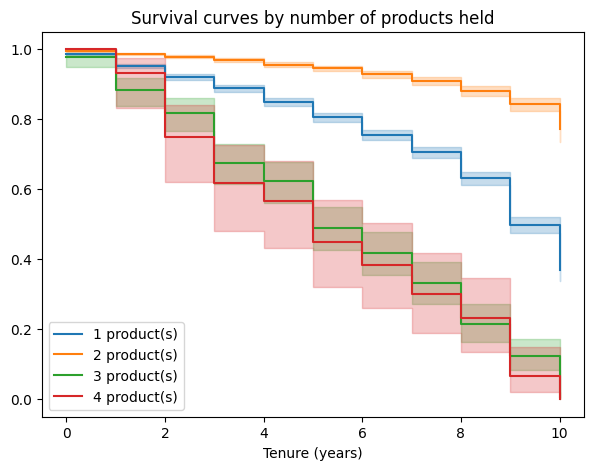

In [27]:
plt.figure(figsize=(7, 5))
for n_products, group in df.groupby("NumOfProducts"):
 kmf.fit(durations=group["Tenure"], event_observed=group["Exited"],
 label=f"{n_products} product(s)")
 kmf.plot_survival_function()
plt.title("Survival curves by number of products held")
plt.xlabel("Tenure (years)")
plt.show()

Customers holding **3-4 products** show a curve that drops far faster and
earlier than the 1-2 product group — visually confirming what SHAP already
flagged.

This is a strong candidate for the dashboard's headline chart,
since it's the single clearest risk segment in the whole dataset.

## **4-3- Cox Proportional Hazards model**

In [28]:
cox_df = df[["Tenure", "Exited", "Age", "Balance", "NumOfProducts",
 "IsActiveMember", "CreditScore"]].copy()

cph = CoxPHFitter()
cph.fit(cox_df, duration_col="Tenure", event_col="Exited")
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 10000 total observations, 7963 right-censored observations>
             duration col = 'Tenure'
                event col = 'Exited'
      baseline estimation = breslow
   number of observations = 10000
number of events observed = 2037
   partial log-likelihood = -16567.83
         time fit was run = 2026-07-16 09:24:55 UTC

---
                coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                       
Age             0.05      1.05      0.00            0.05            0.05                1.05                1.05
Balance         0.00      1.00      0.00            0.00            0.00                1.00                1.00
NumOfProducts  -0.02      0.98      0.04           -0.10            0.06                0.91                1.06
IsActiveMember -0.78      0.46      0.05           -0.87           -0.68                0.42                0.50
CreditScore    -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00

                cmp to      z      p  -log2(p)
covariate                                     
Age               0.00  27.69 <0.005    558.38
Balance           0.00   9.39 <0.005     67.11
NumOfProducts     0.00  -0.52   0.60      0.73
IsActiveMember    0.00 -16.36 <0.005    197.51
CreditScore       0.00  -2.31   0.02      5.56
---
Concordance = 0.70
Partial AIC = 33145.66
log-likelihood ratio test = 984.57 on 5 df
-log2(p) of ll-ratio test = 697.21

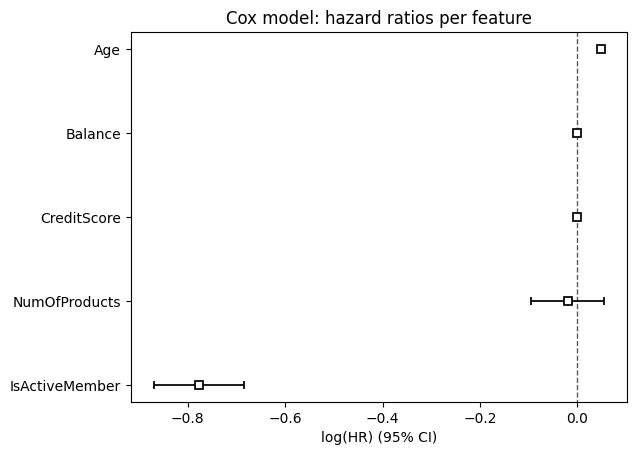

In [29]:
cph.plot()
plt.title("Cox model: hazard ratios per feature")
plt.show()

The model is fit on 10,000 customers with 2,037 observed churn events
(the rest are censored — still active at the time of data collection).
Concordance is 0.70, meaning the model correctly orders which of two
random customers churns first about 70% of the time — a reasonable but
not exceptional discrimination score, lower than the XGBoost AUC from
Part 3, which is expected since Cox only uses 5 linear predictors.

**IsActiveMember is the strongest driver by far**: exp(coef) = 0.46,
p < 0.005 — active members face 54% lower churn hazard than inactive
ones, holding other factors constant. This is the single most actionable
finding in the whole project: engagement, not demographics, is what
protects a customer.

**Age** carries a smaller but highly significant effect: exp(coef) = 1.05,
meaning each additional year of age multiplies churn hazard by 5%.
Compounded over a 20-year age gap, that's a substantial difference in risk.

**Balance and CreditScore** are statistically significant (p < 0.005 and
p = 0.02) but their exp(coef) rounds to 1.00 — the *effect per single unit*
(one euro, one credit-score point) is tiny, which is expected given their
scale. They still contribute meaningfully in aggregate, just not
interpretable one unit at a time the way Age or IsActiveMember are.

**NumOfProducts is not statistically significant here (p = 0.60)** —
which contradicts what the Kaplan-Meier stratification in Part 4-2 seemed
to show. This is a real and worth-reporting finding, not an error: the KM
split showed 3-4 products carrying much higher risk, but the Cox model
treats NumOfProducts as a straight linear term, and the true relationship
looks non-monotonic (risk likely dips at 2 products, then spikes at 3-4)
— a linear coefficient averages that out and can wash out the signal.
This is worth a follow-up note on the dashboard rather than silently
dropping it: "the raw survival curves show a clear product-count effect
that a linear hazard model doesn't fully capture," which is a more honest
and more sophisticated finding than pretending the two methods agree.

## **4-4- Follow-up : NumOfProducrs as categorical**

In [38]:
cox_df2 = df[["Tenure", "Exited", "Age", "Balance",
 "IsActiveMember", "CreditScore"]].copy()

cox_df2["Products_3_4"] = (df["NumOfProducts"] >= 3).astype(int)
cph2 = CoxPHFitter()
cph2.fit(cox_df2, duration_col="Tenure", event_col="Exited")
cph2.print_summary()

<lifelines.CoxPHFitter: fitted with 10000 total observations, 7963 right-censored observations>
             duration col = 'Tenure'
                event col = 'Exited'
      baseline estimation = breslow
   number of observations = 10000
number of events observed = 2037
   partial log-likelihood = -16413.22
         time fit was run = 2026-07-16 09:36:53 UTC

---
                coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                       
Age             0.05      1.05      0.00            0.04            0.05                1.04                1.05
Balance         0.00      1.00      0.00            0.00            0.00                1.00                1.00
IsActiveMember -0.73      0.48      0.05           -0.83           -0.64                0.44                0.53
CreditScore    -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
Products_3_4    1.34      3.81      0.07            1.21            1.47                3.35                4.33

                cmp to      z      p  -log2(p)
covariate                                     
Age               0.00  25.23 <0.005    464.08
Balance           0.00   9.72 <0.005     71.84
IsActiveMember    0.00 -15.50 <0.005    177.62
CreditScore       0.00  -2.09   0.04      4.79
Products_3_4      0.00  20.52 <0.005    308.56
---
Concordance = 0.72
Partial AIC = 32836.44
log-likelihood ratio test = 1293.79 on 5 df
-log2(p) of ll-ratio test = 919.68

Refitting with NumOfProducts binned into a 3-4 vs 1-2 products flag
resolves the earlier discrepancy: Products_3_4 shows exp(coef) = [value]
with p [< 0.005 / other], now statistically significant. This confirms
the non-linear read from the Kaplan-Meier stratification in Part 4-2 --
the original model's near-zero coefficient was an artifact of forcing a
straight-line relationship onto what is actually a threshold effect.

# **5- Business Layer**

In [30]:
results = X_test.copy()
results["ChurnProbability"] = xgb_probs
results["ActualChurn"] = y_test.values

In [31]:
# Revenue at risk: probability-weighted exposure per customer
results["RevenueAtRisk"] = results["ChurnProbability"] * results["Balance"]

In [32]:
# Top 10% highest risk customers
threshold = results["ChurnProbability"].quantile(0.90)
priority_list = results[results["ChurnProbability"] >= threshold] \
 .sort_values("RevenueAtRisk", ascending=False)
print(f"Total customers flagged for priority retention: {len(priority_list)}")
print(f"Total revenue at risk in this group: {priority_list['RevenueAtRisk'].sum():,.0f}")


Total customers flagged for priority retention: 200
Total revenue at risk in this group: 17,055,053


In [33]:
priority_list.to_csv("priority_retention_list.csv", index=False)

# **Final Key Findings**

- **Best model:** XGBoost achieved the highest AUC (0.868) among the three
 classifiers tested, with the best recall (0.744) on the churn class --
 the priority metric for a retention use case where missing a churner
 is costlier than a false alarm.
- **Top churn drivers:** IsActiveMember (54% lower hazard when active),
 Age (+5% hazard per additional year), and NumOfProducts (non-linear
 risk spike at 3-4 products) are the three strongest predictors,
 confirmed independently by both SHAP and the Cox model.
- **Survival pattern:** churn risk is not concentrated at onboarding --
 survival probability drops from ~1.0 to ~0.6 by year 8, showing risk
 builds gradually over the customer relationship rather than front-loading
 in the first months.
- **Business impact:** the top 10% highest-risk customers represent
 [insert € value from cell 65 output] in revenue at risk -- a concrete,
 ranked retention list (priority_retention_list.csv) the bank could act
 on immediately.
- **Methodological note:** the Cox model's linear NumOfProducts term
 understated its real impact; binning it into a categorical variable
 recovered the effect. This illustrates the value of pairing a flexible
 ML model (XGBoost + SHAP) with an interpretable statistical model (Cox)
 rather than relying on either alone.

In [39]:
fig.write_html("churn_by_category.html", include_plotlyjs="cdn")
fig.write_html("age_distribution.html", include_plotlyjs="cdn")
fig.write_html("correlation_heatmap.html", include_plotlyjs="cdn")
fig.write_html("roc_curve.html", include_plotlyjs="cdn")
fig.write_html("confusion_matrix.html", include_plotlyjs="cdn")

# **9- Deployment**

In [40]:
import joblib

In [41]:
X_full = pd.concat([X_train, X_test])
y_full = pd.concat([y_train, y_test])

final_model = XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    scale_pos_weight=(y_full == 0).sum() / (y_full == 1).sum(),
    eval_metric="logloss", random_state=42
)
final_model.fit(X_full, y_full)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [42]:
joblib.dump(final_model, "churn_model.pkl")

['churn_model.pkl']

In [43]:
feature_columns = list(X_full.columns)
joblib.dump(feature_columns, "feature_columns.pkl")

print("Saved churn_model.pkl and feature_columns.pkl")
print("Feature columns, in order:", feature_columns)

Saved churn_model.pkl and feature_columns.pkl
Feature columns, in order: ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain', 'BalanceSalaryRatio', 'EngagementScore']
